# House Classification 2.1

## Data Preparation and Visualisation
This notebook covers the full workflow: data preparation, visual exploration, model development, threshold analysis, and Kaggle test-set classification predictions. It uses the official Kaggle House Prices dataset, creates the `Expensive` classification target from `SalePrice`, and builds a cleaner feature matrix using domain-aware preprocessing.

The Kaggle `test.csv` is kept separate because it does not contain true `SalePrice` labels. It is prepared with the same transformations so it can be used later for prediction.

## 1. Data Loading and Target Setup
We load the official Kaggle files:
- `train.csv`: labelled data with `SalePrice`, used for analysis and training.
- `test.csv`: unlabelled data without `SalePrice`, prepared later for prediction.
- `sample_submission.csv`: example submission format, not a true label source.

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid", palette="deep")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

KAGGLE_DIR = Path("house-prices-advanced-regression-techniques")
TRAIN_PATH = KAGGLE_DIR / "train.csv"
TEST_PATH = KAGGLE_DIR / "test.csv"
SAMPLE_SUBMISSION_PATH = KAGGLE_DIR / "sample_submission.csv"

EXPENSIVE_QUANTILE = 0.85
TARGET_COL = "Expensive"

raw_train = pd.read_csv(TRAIN_PATH)
raw_test = pd.read_csv(TEST_PATH)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)

print("Train shape:", raw_train.shape)
print("Test shape:", raw_test.shape)
print("Sample submission shape:", sample_submission.shape)
print("Train has SalePrice:", "SalePrice" in raw_train.columns)
print("Test has SalePrice:", "SalePrice" in raw_test.columns)
display(raw_train.head())

Train shape: (1460, 81)
Test shape: (1459, 80)
Sample submission shape: (1459, 2)
Train has SalePrice: True
Test has SalePrice: False


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Initial Data Overview
Before cleaning, we inspect shape, data types, duplicates, and the target price distribution. This step prevents accidental assumptions about the dataset.

In [121]:
overview = pd.DataFrame({
    "rows": [raw_train.shape[0], raw_test.shape[0]],
    "columns": [raw_train.shape[1], raw_test.shape[1]],
    "duplicate_rows": [raw_train.duplicated().sum(), raw_test.duplicated().sum()],
    "duplicate_ids": [raw_train["Id"].duplicated().sum(), raw_test["Id"].duplicated().sum()],
}, index=["train", "test"])

print("Dataset overview:")
display(overview)

print("Missing values in train dataset:")
dtype_summary = raw_train.dtypes.value_counts().rename_axis("dtype").reset_index(name="count")
display(dtype_summary)

print("SalePrice distribution summary:")
display(raw_train["SalePrice"].describe().to_frame().round(2).T)

Dataset overview:


,rows,columns,duplicate_rows,duplicate_ids
train,1460,81,0,0
test,1459,80,0,0


Missing values in train dataset:


,dtype,count
0,object,43
1,int64,35
2,float64,3


SalePrice distribution summary:


,count,mean,std,min,25%,50%,75%,max
SalePrice,1460.0,180921.2,79442.5,34900.0,129975.0,163000.0,214000.0,755000.0


### Create Classification Target
`Expensive` is created from houses at or above the 85th percentile of `SalePrice`, giving approximately the top 15% of houses. The continuous `SalePrice` column is used only to create the target and is removed before the final feature matrix to avoid leakage.

In [122]:
EXPENSIVE_THRESHOLD = raw_train["SalePrice"].quantile(EXPENSIVE_QUANTILE)

train_with_target = raw_train.copy()
train_with_target[TARGET_COL] = (train_with_target["SalePrice"] >= EXPENSIVE_THRESHOLD).astype(int)

print(f"Expensive threshold: SalePrice >= {EXPENSIVE_THRESHOLD:,.0f}")
print("Class counts:")
print(train_with_target[TARGET_COL].value_counts())
print("\nClass percentages:")
print((train_with_target[TARGET_COL].value_counts(normalize=True) * 100).round(2))

Expensive threshold: SalePrice >= 250,000
Class counts:
0    1235
1     225
Name: Expensive, dtype: int64

Class percentages:
0    84.59
1    15.41
Name: Expensive, dtype: float64


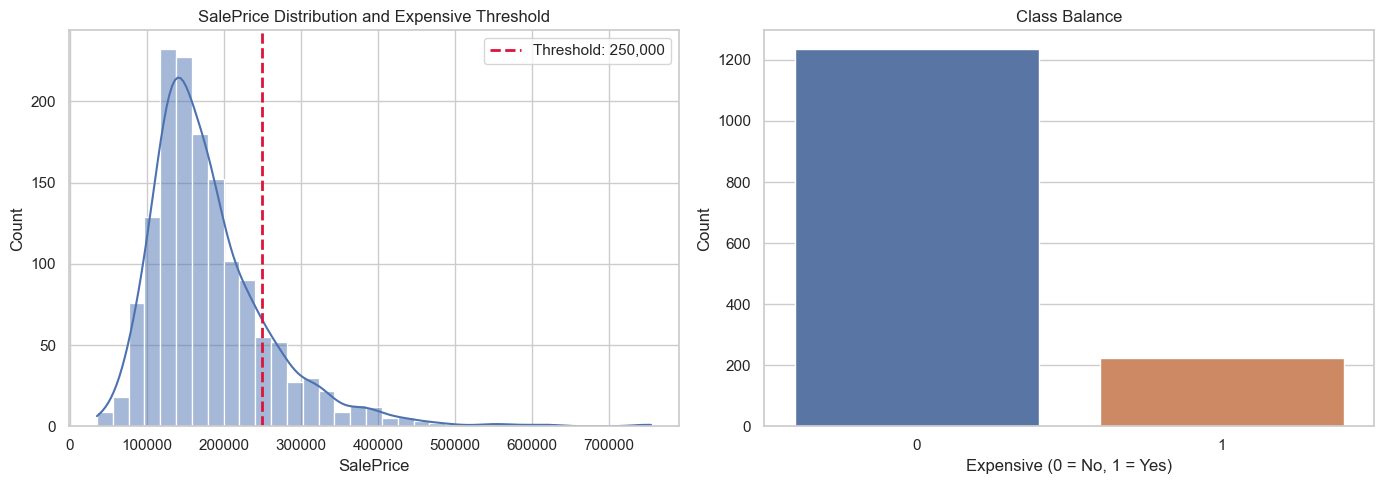

In [123]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(raw_train["SalePrice"], kde=True, bins=35, ax=axes[0])
axes[0].axvline(EXPENSIVE_THRESHOLD, color="crimson", linestyle="--", linewidth=2, label=f"Threshold: {EXPENSIVE_THRESHOLD:,.0f}")
axes[0].set_title("SalePrice Distribution and Expensive Threshold")
axes[0].set_xlabel("SalePrice")
axes[0].legend()

sns.countplot(data=train_with_target, x=TARGET_COL, ax=axes[1])
axes[1].set_title("Class Balance")
axes[1].set_xlabel("Expensive (0 = No, 1 = Yes)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

**Plot interpretation:** The SalePrice histogram shows a right-skewed price distribution: most houses are in the lower-to-middle price range, while a smaller number of properties are very expensive. The red threshold line marks the cutoff used to create `Expensive = 1`. The class-balance plot confirms that this is an imbalanced classification problem, with many more non-expensive houses than expensive houses.

## 2. Data Cleaning and Feature Preparation
Missing values have different meanings in this dataset. Some missing values mean absence of a feature, such as no garage or no basement. Others are unknown numeric values and need imputation.

,PoolQC,MiscFeature,Alley,Fence,FireplaceQu,LotFrontage,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,BsmtExposure,BsmtFinType2,BsmtFinType1,BsmtCond,BsmtQual,MasVnrArea,MasVnrType,Electrical
missing_count,1453.000000,1406.00000,1369.000000,1179.000000,690.000000,259.000000,81.000000,81.000000,81.000000,81.000000,81.000000,38.00000,38.00000,37.000000,37.000000,37.000000,8.000000,8.000000,1.000000
missing_percent,99.520548,96.30137,93.767123,80.753425,47.260274,17.739726,5.547945,5.547945,5.547945,5.547945,5.547945,2.60274,2.60274,2.534247,2.534247,2.534247,0.547945,0.547945,0.068493


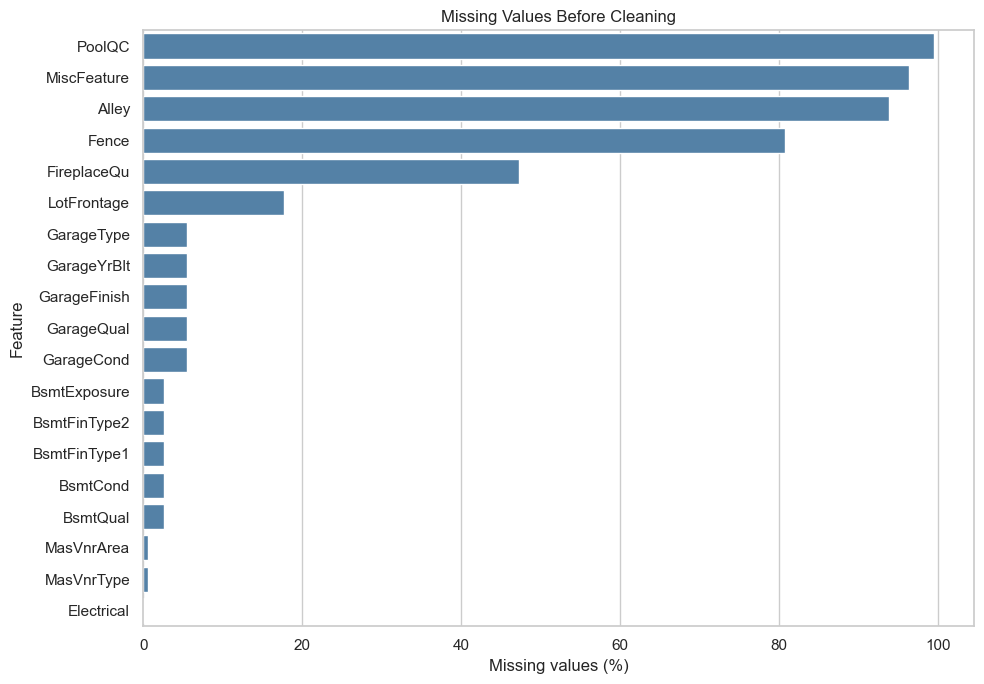

In [124]:
def missing_table(df):
    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100,
    })
    return missing[missing["missing_count"] > 0].sort_values("missing_percent", ascending=False)

missing_before = missing_table(train_with_target)
display(missing_before.T)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=missing_before.reset_index().rename(columns={"index": "feature"}),
    x="missing_percent",
    y="feature",
    color="steelblue",
)
plt.title("Missing Values Before Cleaning")
plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Plot interpretation:** The missing-value plot shows that missingness is concentrated in a small set of housing features. Many of these missing values are meaningful rather than random: for example, missing `PoolQC`, `Alley`, `Fence`, or garage/basement quality often means the house does not have that feature. This supports using domain-aware filling instead of simple blanket imputation.

### Domain-Aware Missing Value Treatment
The Kaggle data description shows that several `NaN` values mean the house does not have that feature. These columns are identified here and filled later inside the reusable cleaning function: categorical absence values are filled with `None`, while numeric area/count absence values are filled with `0`.

`LotFrontage` is treated differently: it is filled with the median frontage of the same `Neighborhood`, because nearby houses usually have similar street frontage.

In [125]:
none_fill_cols = [
    "Alley", "PoolQC", "Fence", "MiscFeature", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType",
]

zero_fill_cols = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "MasVnrArea",
]

print("Categorical absence columns present:", [c for c in none_fill_cols if c in raw_train.columns])
print("Numeric absence columns present:", [c for c in zero_fill_cols if c in raw_train.columns])

Categorical absence columns present: ['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
Numeric absence columns present: ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']


### Outlier Analysis
The original Kaggle competition discussion commonly flags very large houses with unusually low prices. We visualise these points before deciding whether to remove them from the training data.

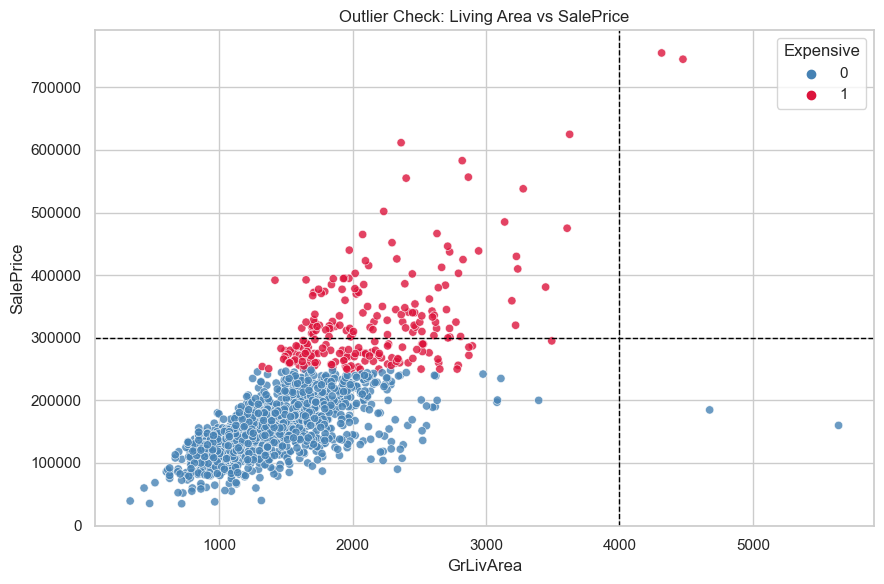

Potential outlier Ids: [524, 1299]


,Id,GrLivArea,SalePrice,Expensive
523,524,4676,184750,0
1298,1299,5642,160000,0


In [126]:
outlier_mask = (train_with_target["GrLivArea"] > 4000) & (train_with_target["SalePrice"] < 300000)
outlier_ids = train_with_target.loc[outlier_mask, "Id"].tolist()

plt.figure(figsize=(9, 6))
sns.scatterplot(data=train_with_target, x="GrLivArea", y="SalePrice", 
                hue=TARGET_COL, palette={0: "steelblue", 1: "crimson"}, alpha=0.8)
plt.axvline(4000, color="black", linestyle="--", linewidth=1)
plt.axhline(300000, color="black", linestyle="--", linewidth=1)
plt.title("Outlier Check: Living Area vs SalePrice")
plt.tight_layout()
plt.show()

print("Potential outlier Ids:", outlier_ids)
display(train_with_target.loc[outlier_mask, ["Id", "GrLivArea", "SalePrice", TARGET_COL]])

**Plot interpretation:** The scatterplot compares living area with sale price. Most houses follow the expected pattern where larger living area is associated with higher price. The dashed threshold lines identify two extreme cases with very large living areas and relatively low sale prices; these rows are displayed below and removed from the training analysis to reduce distortion.

In [127]:
train_analysis = train_with_target.loc[~outlier_mask].copy()
print("Rows before outlier removal:", len(train_with_target))
print("Rows after outlier removal:", len(train_analysis))
print("Rows removed:", int(outlier_mask.sum()))

Rows before outlier removal: 1460
Rows after outlier removal: 1458
Rows removed: 2


### Feature Engineering
Create features that better represent housing value drivers:
- total usable square footage,
- total bathrooms,
- house age and remodel age,
- binary indicators for garage, basement, fireplace, pool, porch, and second floor.

In [128]:
def add_engineered_features(df):
    df = df.copy()
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBathrooms"] = (
        df["FullBath"] + 0.5 * df["HalfBath"] +
        df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
    )
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["IsRemodeled"] = (df["YearBuilt"] != df["YearRemodAdd"]).astype(int)
    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
    df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["HasPool"] = (df["PoolArea"] > 0).astype(int)
    df["HasPorch"] = ((df["OpenPorchSF"] + df["EnclosedPorch"] 
                       + df["3SsnPorch"] + df["ScreenPorch"]) > 0).astype(int)
    df["HasSecondFloor"] = (df["2ndFlrSF"] > 0).astype(int)
    return df

feature_demo = add_engineered_features(train_analysis.drop(columns=["SalePrice"]))
new_features = ["TotalSF", "TotalBathrooms", "HouseAge", "RemodelAge", "IsRemodeled", "HasGarage",
                "HasBasement", "HasFireplace", "HasPool", "HasPorch", "HasSecondFloor"]
display(feature_demo[new_features + [TARGET_COL]].head())

,TotalSF,TotalBathrooms,HouseAge,RemodelAge,IsRemodeled,HasGarage,HasBasement,HasFireplace,HasPool,HasPorch,HasSecondFloor,Expensive
0,2566,3.5,5,5,0,1,1,0,0,1,1,0
1,2524,2.5,31,31,0,1,1,1,0,0,0,0
2,2706,3.5,7,6,1,1,1,1,0,1,1,0
3,2473,2.0,91,36,1,1,1,1,0,1,1,0
4,3343,3.5,8,8,0,1,1,1,0,1,1,1


### Reusable Cleaning Pipeline for Train and Test
This stage creates metadata from the training data, then applies the same cleaning logic to both train and test. This prevents train/test mismatch later. For a stricter production workflow, preprocessing metadata should be fitted only on the training split inside a pipeline. Here, the full Kaggle training data is cleaned first to support EDA and notebook readability.

In [129]:
def fit_preprocessing_metadata(train_df, target_col=TARGET_COL, rare_min_count=10):
    feature_df = train_df.drop(columns=[target_col, "SalePrice"], errors="ignore").copy()

    neighborhood_frontage = feature_df.groupby("Neighborhood")["LotFrontage"].median()
    global_frontage = feature_df["LotFrontage"].median()

    categorical_cols = feature_df.select_dtypes(include="object").columns.tolist()
    numeric_cols = feature_df.select_dtypes(exclude="object").columns.tolist()

    categorical_modes = feature_df[categorical_cols].mode(dropna=True).iloc[0].to_dict()
    numeric_medians = feature_df[numeric_cols].median(numeric_only=True).to_dict()

    rare_levels = {}
    for col in categorical_cols:
        counts = feature_df[col].fillna("Missing").value_counts()
        rare_levels[col] = counts[counts < rare_min_count].index.tolist()

    return {
        "neighborhood_frontage": neighborhood_frontage,
        "global_frontage": global_frontage,
        "categorical_modes": categorical_modes,
        "numeric_medians": numeric_medians,
        "rare_levels": rare_levels,
        "rare_min_count": rare_min_count,
    }


def clean_housing_features(df, metadata, target_col=TARGET_COL):
    df = df.copy()
    target = df[target_col].copy() if target_col in df.columns else None

    df = df.drop(columns=[target_col, "SalePrice"], errors="ignore")
    df = df.drop(columns=["Id"], errors="ignore")

    for col in none_fill_cols:
        if col in df.columns:
            df[col] = df[col].fillna("None")

    for col in zero_fill_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    if "LotFrontage" in df.columns:
        frontage_by_neighborhood = df["Neighborhood"].map(metadata["neighborhood_frontage"])
        df["LotFrontage"] = df["LotFrontage"].fillna(frontage_by_neighborhood)
        df["LotFrontage"] = df["LotFrontage"].fillna(metadata["global_frontage"])

    categorical_cols = df.select_dtypes(include="object").columns.tolist()
    numeric_cols = df.select_dtypes(exclude="object").columns.tolist()

    for col in categorical_cols:
        fill_value = metadata["categorical_modes"].get(col, "Missing")
        df[col] = df[col].fillna(fill_value)
        rare = metadata["rare_levels"].get(col, [])
        df[col] = df[col].where(~df[col].isin(rare), "Rare")

    for col in numeric_cols:
        fill_value = metadata["numeric_medians"].get(col, df[col].median())
        df[col] = df[col].fillna(fill_value)

    df = add_engineered_features(df)

    if target is not None:
        df[target_col] = target.values

    return df

preprocessing_metadata = fit_preprocessing_metadata(train_analysis)
clean_train = clean_housing_features(train_analysis, preprocessing_metadata)
clean_test = clean_housing_features(raw_test, preprocessing_metadata)

print("Clean train shape:", clean_train.shape)
print("Clean test shape:", clean_test.shape)
print("Missing values in clean train:", int(clean_train.isna().sum().sum()))
print("Missing values in clean test:", int(clean_test.isna().sum().sum()))
display(clean_train.head())

Clean train shape: (1458, 91)
Clean test shape: (1459, 90)
Missing values in clean train: 0
Missing values in clean test: 0


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalBathrooms,HouseAge,RemodelAge,IsRemodeled,HasGarage,HasBasement,HasFireplace,HasPool,HasPorch,HasSecondFloor,Expensive
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,2566,3.5,5,5,0,1,1,0,0,1,1,0
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,2524,2.5,31,31,0,1,1,1,0,0,0,0
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,2706,3.5,7,6,1,1,1,1,0,1,1,0
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,2473,2.0,91,36,1,1,1,1,0,1,1,0
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,3343,3.5,8,8,0,1,1,1,0,1,1,1


In [130]:
missing_after = missing_table(clean_train)

if missing_after.empty:
    print("No missing values remain in clean_train.")
else:
    display(missing_after)

summary_before_after = pd.DataFrame({
    "stage": ["before_cleaning", "after_cleaning"],
    "total_missing_values": [int(train_analysis.isna().sum().sum()), int(clean_train.isna().sum().sum())],
    "columns_with_missing": [int((train_analysis.isna().sum() > 0).sum()), int((clean_train.isna().sum() > 0).sum())],
})
display(summary_before_after)

No missing values remain in clean_train.


,stage,total_missing_values,columns_with_missing
0,before_cleaning,6958,19
1,after_cleaning,0,0


## 3. Visual Exploration After Cleaning
These plots check whether the engineered and cleaned data behaves sensibly before modelling.

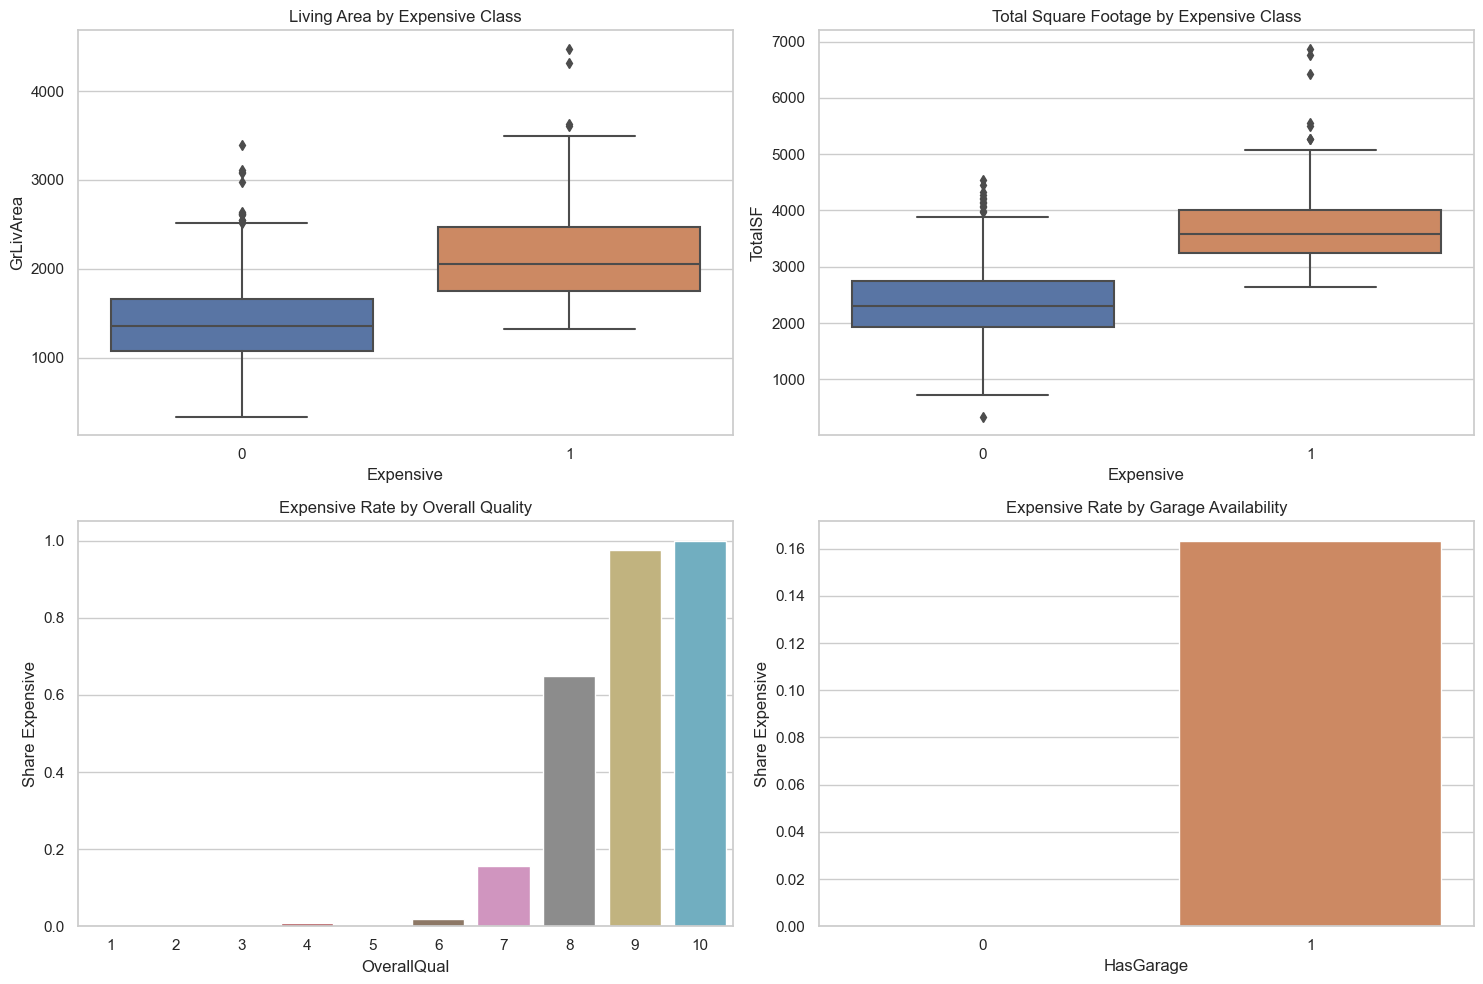

In [131]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(data=clean_train, x=TARGET_COL, y="GrLivArea", ax=axes[0, 0])
axes[0, 0].set_title("Living Area by Expensive Class")

sns.boxplot(data=clean_train, x=TARGET_COL, y="TotalSF", ax=axes[0, 1])
axes[0, 1].set_title("Total Square Footage by Expensive Class")

sns.barplot(data=clean_train, x="OverallQual", y=TARGET_COL, ax=axes[1, 0], errorbar=None)
axes[1, 0].set_title("Expensive Rate by Overall Quality")
axes[1, 0].set_ylabel("Share Expensive")

sns.barplot(data=clean_train, x="HasGarage", y=TARGET_COL, ax=axes[1, 1], errorbar=None)
axes[1, 1].set_title("Expensive Rate by Garage Availability")
axes[1, 1].set_ylabel("Share Expensive")

plt.tight_layout()
plt.show()

**Plot interpretation:** These plots check whether key cleaned and engineered features separate expensive from non-expensive houses. Expensive houses generally have larger living area, larger total square footage, higher overall quality, and are more likely to have a garage. This confirms that the engineered features are aligned with real housing-value logic.

,mean,count
Neighborhood,,
CollgCr,0.120000,150
SawyerW,0.135593,59
ClearCr,0.214286,28
Crawfor,0.235294,51
Somerst,0.313953,86
Veenker,0.363636,11
Timber,0.421053,38
StoneBr,0.640000,25
NridgHt,0.766234,77


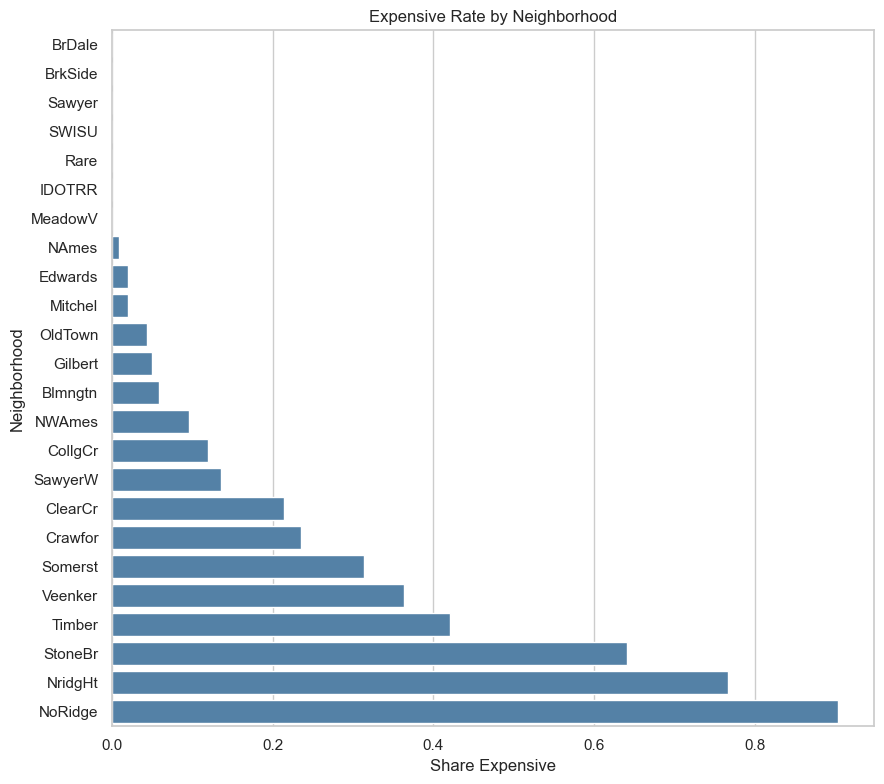

In [132]:
neighborhood_rate = clean_train.groupby("Neighborhood")[TARGET_COL].agg(["mean", "count"]).sort_values("mean")

display(neighborhood_rate.tail(10))

plt.figure(figsize=(9, 8))
sns.barplot(data=neighborhood_rate.reset_index(), x="mean", y="Neighborhood", color="steelblue")
plt.title("Expensive Rate by Neighborhood")
plt.xlabel("Share Expensive")
plt.ylabel("Neighborhood")
plt.tight_layout()
plt.show()

**Plot interpretation:** The neighbourhood chart shows that location has a strong relationship with the expensive-house class. Some neighbourhoods have a much higher share of expensive properties than others. This means `Neighborhood` should be kept as an important categorical predictor during modelling.

,correlation_with_expensive
TotalSF,0.627897
OverallQual,0.600052
GrLivArea,0.548238
TotalBsmtSF,0.496909
GarageArea,0.488667
1stFlrSF,0.488638
GarageCars,0.464250
TotalBathrooms,0.422503
TotRmsAbvGrd,0.406707
MasVnrArea,0.394407


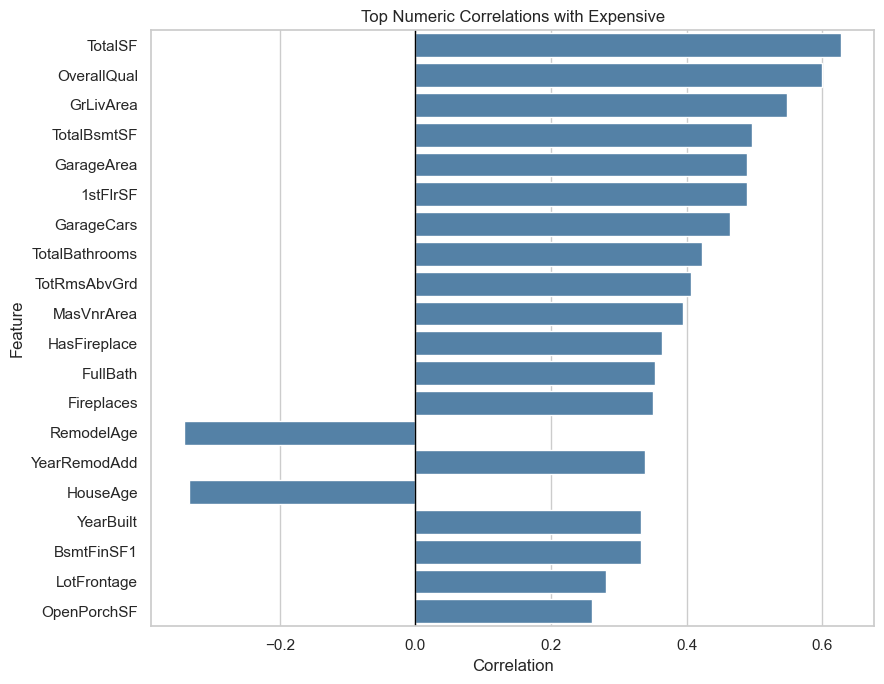

In [133]:
numeric_corr = clean_train.select_dtypes(include="number").corr()[TARGET_COL].drop(TARGET_COL).sort_values(key=lambda s: s.abs(), ascending=False)

display(numeric_corr.head(20).to_frame("correlation_with_expensive"))

plt.figure(figsize=(9, 7))
sns.barplot(x=numeric_corr.head(20).values, y=numeric_corr.head(20).index, color="steelblue")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top Numeric Correlations with Expensive")
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Plot interpretation:** The correlation chart ranks numeric variables by their relationship with `Expensive`. Quality, size, basement area, garage capacity, and engineered total-area features are among the strongest signals. Correlation does not prove causation, but it helps identify which numeric features are most useful before modelling.

## 4. Final Clean Feature Matrix
At this point, the data is ready for modelling. `clean_train` contains the target, while `X_clean` and `y_clean` separate features from labels. `clean_test` has the same feature-preparation logic applied to Kaggle's unlabelled test data.

In [134]:
X_clean = clean_train.drop(columns=[TARGET_COL])
y_clean = clean_train[TARGET_COL]

print("X_clean shape:", X_clean.shape)
print("y_clean shape:", y_clean.shape)
print("clean_test shape:", clean_test.shape)
print("Feature columns match test columns:", list(X_clean.columns) == list(clean_test.columns))

clean_summary = pd.DataFrame({
    "dataset": ["X_clean", "clean_test"],
    "rows": [X_clean.shape[0], clean_test.shape[0]],
    "columns": [X_clean.shape[1], clean_test.shape[1]],
    "missing_values": [int(X_clean.isna().sum().sum()), int(clean_test.isna().sum().sum())],
})
print("Cleaned dataset summary:")
display(clean_train.head())
print("\nSummary of cleaned datasets:")
display(clean_summary)
display(clean_train.info())

X_clean shape: (1458, 90)
y_clean shape: (1458,)
clean_test shape: (1459, 90)
Feature columns match test columns: True
Cleaned dataset summary:


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalBathrooms,HouseAge,RemodelAge,IsRemodeled,HasGarage,HasBasement,HasFireplace,HasPool,HasPorch,HasSecondFloor,Expensive
0,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,2566,3.5,5,5,0,1,1,0,0,1,1,0
1,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,2524,2.5,31,31,0,1,1,1,0,0,0,0
2,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,2706,3.5,7,6,1,1,1,1,0,1,1,0
3,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,2473,2.0,91,36,1,1,1,1,0,1,1,0
4,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,3343,3.5,8,8,0,1,1,1,0,1,1,1



Summary of cleaned datasets:


,dataset,rows,columns,missing_values
0,X_clean,1458,90,0
1,clean_test,1459,90,0


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1458 entries, 0 to 1459
Data columns (total 91 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MSSubClass      1458 non-null   int64  
 1   MSZoning        1458 non-null   object 
 2   LotFrontage     1458 non-null   float64
 3   LotArea         1458 non-null   int64  
 4   Street          1458 non-null   object 
 5   Alley           1458 non-null   object 
 6   LotShape        1458 non-null   object 
 7   LandContour     1458 non-null   object 
 8   Utilities       1458 non-null   object 
 9   LotConfig       1458 non-null   object 
 10  LandSlope       1458 non-null   object 
 11  Neighborhood    1458 non-null   object 
 12  Condition1      1458 non-null   object 
 13  Condition2      1458 non-null   object 
 14  BldgType        1458 non-null   object 
 15  HouseStyle      1458 non-null   object 
 16  OverallQual     1458 non-null   int64  
 17  OverallCond     1458 non-null   i

None

### Preprocessing Summary
The data-preparation stage now includes:
- Kaggle `train.csv` as the labelled modelling dataset.
- Kaggle `test.csv` kept separate for future prediction.
- Explicit `Expensive` target creation from the top 15% of `SalePrice`.
- `SalePrice` removed from features to prevent leakage.
- Domain-aware missing-value handling for basement, garage, pool, fence, alley, masonry veneer, and fireplace fields.
- Neighbourhood-median imputation for `LotFrontage`.
- Removal of the non-predictive `Id` feature.
- Rare category grouping to reduce noisy one-hot encoding later.
- Feature engineering for area, bathrooms, age, remodel status, and feature-availability indicators.
- Outlier review and removal of extreme `GrLivArea`/low-price points from the training analysis data.

The next section starts modelling from `X_clean`, `y_clean`, and `clean_test`.

## 5. Model Development
This section starts modelling from the cleaned dataset created above. The goal is to compare several models fairly using the same train/test split and the same encoding strategy.

Because the target is imbalanced, model choice focuses on the expensive-house class: recall, F1-score, PR-AUC, and false negatives are more important than accuracy alone.

### Train/Test Split
We use a stratified split so both train and test sets keep the same expensive/non-expensive class ratio.

In [135]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    average_precision_score, precision_recall_curve
)
from sklearn.inspection import permutation_importance

X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y_clean,
    test_size=0.2,
    stratify=y_clean,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))

Train shape: (1166, 90)
Test shape: (292, 90)
Train class balance:
0    0.846
1    0.154
Name: Expensive, dtype: float64

Test class balance:
0    0.846
1    0.154
Name: Expensive, dtype: float64


### Modelling Preprocessor
Numeric features are median-imputed and scaled for linear models. Categorical features are one-hot encoded with `handle_unknown="ignore"`, which is important because the Kaggle test set may contain categories not seen during training.

In [136]:
numeric_features = X_clean.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_clean.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess_scaled = ColumnTransformer(transformers=[
    ("num", numeric_scaled, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

preprocess_tree = ColumnTransformer(transformers=[
    ("num", numeric_unscaled, numeric_features),
    ("cat", categorical_pipe, categorical_features),
])

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 47
Categorical features: 43


### Baseline and Candidate Models
The dummy baseline shows what happens if the model always predicts the majority class. The real candidate models include interpretable Logistic Regression and stronger tree-based ensemble models.

In [137]:
models = {
    "Dummy baseline": Pipeline(steps=[
        ("prep", preprocess_scaled),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]),
    "Logistic Regression": Pipeline(steps=[
        ("prep", preprocess_scaled),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ]),
    "Balanced Logistic Regression": Pipeline(steps=[
        ("prep", preprocess_scaled),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("prep", preprocess_tree),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("prep", preprocess_tree),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
}

param_grids = {
    "Dummy baseline": {},
    "Logistic Regression": {"model__C": [0.1, 1, 10]},
    "Balanced Logistic Regression": {"model__C": [0.1, 1, 10]},
    "Random Forest": {
        "model__n_estimators": [200],
        "model__max_depth": [None, 8, 16],
        "model__min_samples_leaf": [1, 3, 5],
        "model__class_weight": [None, "balanced"],
    },
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3],
        "model__min_samples_leaf": [1, 5],
    },
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
searches = {}

for name, model in models.items():
    search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[name],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True,
    )
    search.fit(X_train, y_train)
    searches[name] = search
    print(f"{name}: best CV F1 = {search.best_score_:.3f}")
    print("Best params:", search.best_params_)

Dummy baseline: best CV F1 = 0.000
Best params: {}
Logistic Regression: best CV F1 = 0.851
Best params: {'model__C': 1}
Balanced Logistic Regression: best CV F1 = 0.850
Best params: {'model__C': 1}
Random Forest: best CV F1 = 0.837
Best params: {'model__class_weight': 'balanced', 'model__max_depth': 8, 'model__min_samples_leaf': 3, 'model__n_estimators': 200}
Gradient Boosting: best CV F1 = 0.839
Best params: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


### Model Evaluation
This evaluation uses the held-out test set. The confusion matrix is especially important because false negatives represent expensive houses missed by the model.

In [138]:
def evaluate_classifier(model, name, threshold=0.5):
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)
    else:
        y_pred = model.predict(X_test)
        y_proba = None
        roc_auc = np.nan
        pr_auc = np.nan

    cm = confusion_matrix(y_test, y_pred)
    row = {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision_expensive": precision_score(y_test, y_pred, zero_division=0),
        "recall_expensive": recall_score(y_test, y_pred, zero_division=0),
        "f1_expensive": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "false_negatives": int(cm[1, 0]),
        "false_positives": int(cm[0, 1]),
        "total_mistakes": int((y_test != y_pred).sum()),
    }

    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, digits=3, zero_division=0))
    print("Confusion matrix:")
    print(cm)
    return row

results = []
best_estimators = {}
for name, search in searches.items():
    best_estimators[name] = search.best_estimator_
    results.append(evaluate_classifier(search.best_estimator_, name))

results_df = pd.DataFrame(results).sort_values(
    by=["f1_expensive", "recall_expensive", "false_negatives"],
    ascending=[False, False, True],
)

display(results_df.round(3))


=== Dummy baseline ===
              precision    recall  f1-score   support

           0      0.846     1.000     0.917       247
           1      0.000     0.000     0.000        45

    accuracy                          0.846       292
   macro avg      0.423     0.500     0.458       292
weighted avg      0.716     0.846     0.775       292

Confusion matrix:
[[247   0]
 [ 45   0]]

=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.976     0.972     0.974       247
           1      0.848     0.867     0.857        45

    accuracy                          0.955       292
   macro avg      0.912     0.919     0.915       292
weighted avg      0.956     0.955     0.956       292

Confusion matrix:
[[240   7]
 [  6  39]]

=== Balanced Logistic Regression ===
              precision    recall  f1-score   support

           0      0.979     0.947     0.963       247
           1      0.755     0.889     0.816        45

    accur

,model,threshold,accuracy,precision_expensive,recall_expensive,f1_expensive,roc_auc,pr_auc,false_negatives,false_positives,total_mistakes
4,Gradient Boosting,0.5,0.955,0.833,0.889,0.860,0.991,0.953,5,8,13
1,Logistic Regression,0.5,0.955,0.848,0.867,0.857,0.987,0.939,6,7,13
3,Random Forest,0.5,0.949,0.768,0.956,0.851,0.984,0.913,2,13,15
2,Balanced Logistic Regression,0.5,0.938,0.755,0.889,0.816,0.985,0.927,5,13,18
0,Dummy baseline,0.5,0.846,0.000,0.000,0.000,0.500,0.154,45,0,45


### Model Comparison Visualisations
The table above is useful, but visual comparisons make the tradeoffs easier to see. These plots compare overall performance, expensive-class performance, and false negatives.

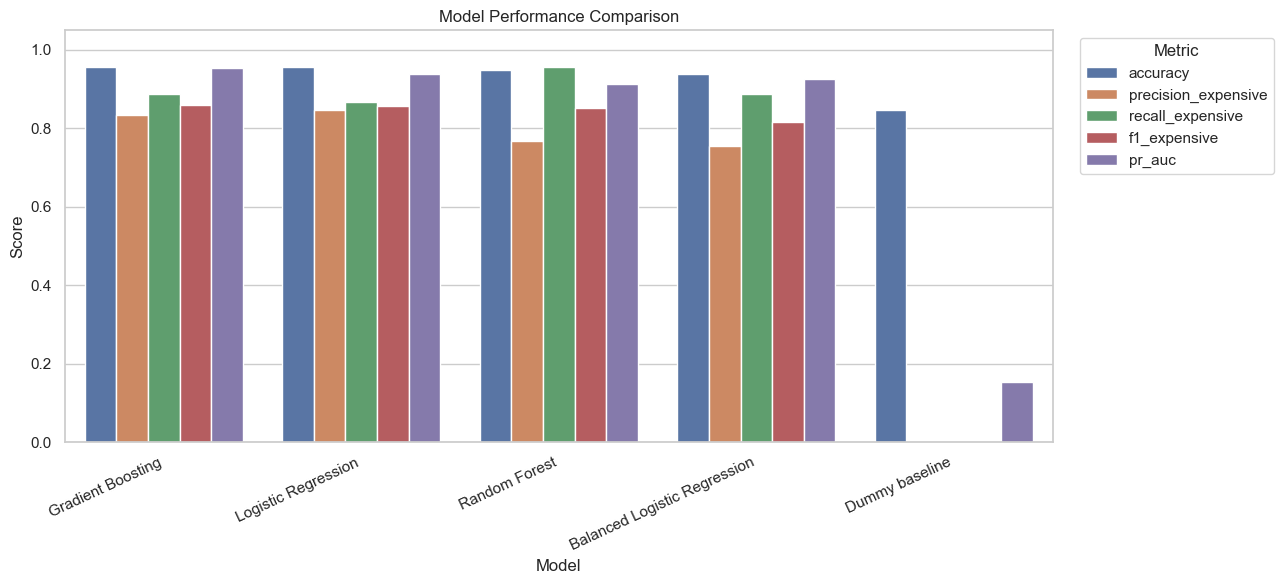

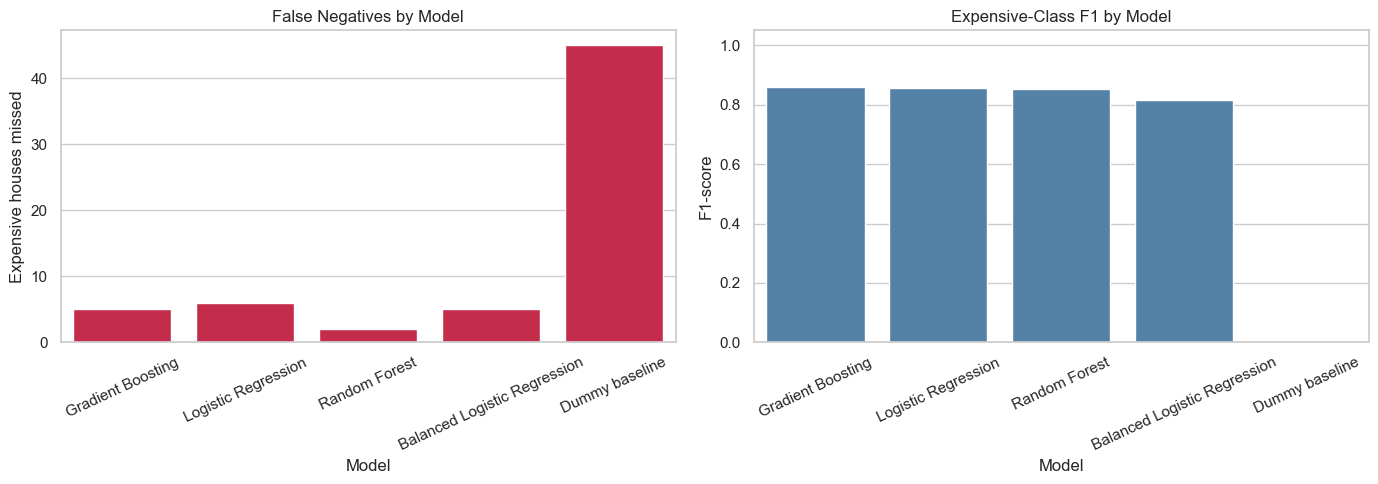

In [139]:
plot_metrics = [
    "accuracy", "precision_expensive", "recall_expensive",
    "f1_expensive", "pr_auc"
]

metric_plot_df = results_df.melt(
    id_vars="model",
    value_vars=plot_metrics,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(13, 6))
sns.barplot(data=metric_plot_df, x="model", y="score", hue="metric")
plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x="model", y="false_negatives", ax=axes[0], color="crimson")
axes[0].set_title("False Negatives by Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("Expensive houses missed")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=results_df, x="model", y="f1_expensive", ax=axes[1], color="steelblue")
axes[1].set_title("Expensive-Class F1 by Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("F1-score")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

**Visual interpretation:** Logistic Regression has the strongest default expensive-class F1, while Random Forest misses the fewest expensive houses. This confirms the main tradeoff: choose Logistic Regression for balanced overall classification performance, or Random Forest if reducing false negatives is the priority.

### Confusion Matrix Visualisations
Confusion matrices show the actual error types. The bottom-left cell is the most important here: it contains false negatives, meaning expensive houses predicted as non-expensive.

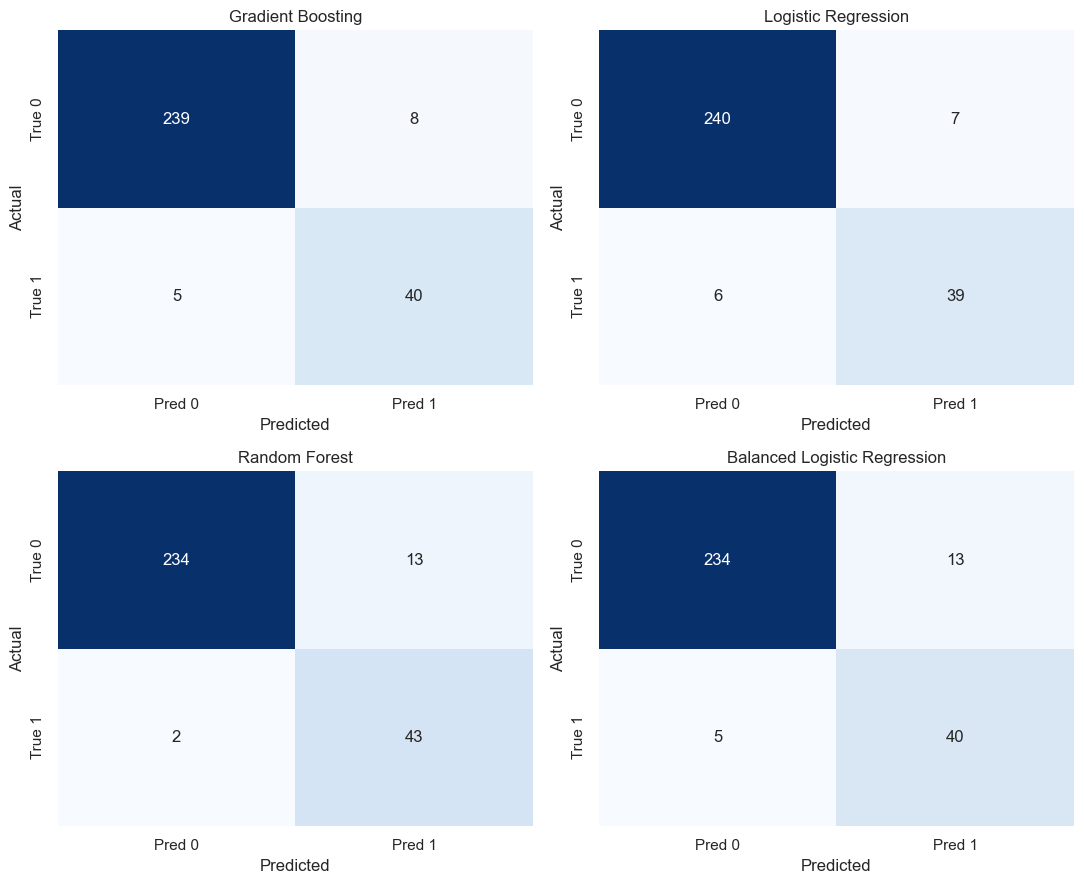

In [140]:
models_for_cm = [name for name in results_df["model"] if name != "Dummy baseline"]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.ravel()

for ax, name in zip(axes, models_for_cm[:4]):
    model = best_estimators[name]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"],
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes[len(models_for_cm[:4]):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Confusion-matrix interpretation:** Random Forest produces the smallest number of false negatives in the default setting, meaning it catches more expensive houses. Logistic Regression has fewer false positives, so it is more conservative when assigning the expensive label.

### ROC-AUC and PR-AUC Visualisations
This section compares model performance across probability thresholds using ROC and Precision-Recall curves. ROC-AUC measures general ranking ability, while PR-AUC is more informative for this imbalanced classification problem because expensive houses are the minority class.

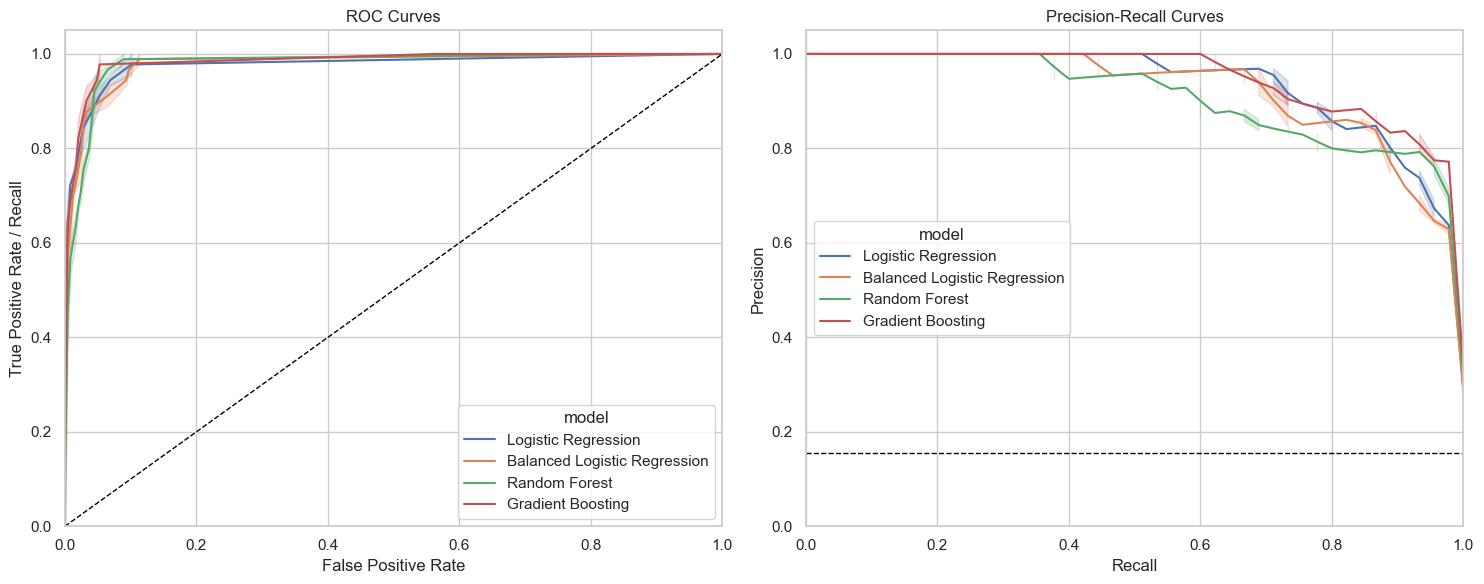

,model,roc_auc,pr_auc
3,Gradient Boosting,0.991,0.953
0,Logistic Regression,0.987,0.939
1,Balanced Logistic Regression,0.985,0.927
2,Random Forest,0.984,0.913


In [141]:
from sklearn.metrics import roc_curve, auc

curve_rows = []
auc_rows = []

for name, model in best_estimators.items():
    if name == "Dummy baseline" or not hasattr(model, "predict_proba"):
        continue

    y_proba = model.predict_proba(X_test)[:, 1]

    fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
    precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)

    roc_auc_value = roc_auc_score(y_test, y_proba)
    pr_auc_value = average_precision_score(y_test, y_proba)
    auc_rows.append({
        "model": name,
        "roc_auc": roc_auc_value,
        "pr_auc": pr_auc_value,
    })

    for x, y in zip(fpr, tpr):
        curve_rows.append({"model": name, "curve": "ROC", "x": x, "y": y})

    for x, y in zip(recall, precision):
        curve_rows.append({"model": name, "curve": "Precision-Recall", "x": x, "y": y})

curve_df = pd.DataFrame(curve_rows)
auc_df = pd.DataFrame(auc_rows).sort_values("pr_auc", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

roc_df = curve_df[curve_df["curve"] == "ROC"]
sns.lineplot(data=roc_df, x="x", y="y", hue="model", ax=axes[0])
axes[0].plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1)
axes[0].set_title("ROC Curves")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate / Recall")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)

pr_df = curve_df[curve_df["curve"] == "Precision-Recall"]
sns.lineplot(data=pr_df, x="x", y="y", hue="model", ax=axes[1])
base_rate = y_test.mean()
axes[1].axhline(base_rate, color="black", linestyle="--", linewidth=1, label=f"Base rate: {base_rate:.2f}")
axes[1].set_title("Precision-Recall Curves")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

display(auc_df.round(3))

**ROC/PR interpretation:** ROC-AUC is useful for overall ranking quality, but PR-AUC is more informative for this project because expensive houses are the minority class. A stronger Precision-Recall curve means the model can catch expensive houses while keeping false expensive predictions under control.

**Model comparison interpretation:** The best model should not be chosen by accuracy alone. For this business problem, the preferred model is the one that gives strong expensive-class F1 while keeping false negatives low. A model with slightly lower accuracy may be better if it misses fewer expensive houses.

### Threshold Tuning
The default probability threshold is `0.5`. If false negatives are more costly, changing the threshold can improve recall for expensive houses. Thresholds are selected on a validation split, then checked on the held-out test set.

In [142]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

threshold_rows = []

for name, search in searches.items():
    if name == "Dummy baseline":
        continue

    model = search.best_estimator_
    model.fit(X_tr, y_tr)
    val_proba = model.predict_proba(X_val)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_val, val_proba)
    f1_values = 2 * (precision * recall) / (precision + recall + 1e-12)

    best_idx = np.argmax(f1_values[:-1])
    best_threshold = thresholds[best_idx]

    # Refit on the full training split before testing the selected threshold.
    final_model = search.best_estimator_
    final_model.fit(X_train, y_train)
    row = evaluate_classifier(final_model, f"{name} tuned threshold", threshold=best_threshold)
    row["validation_f1_at_threshold"] = f1_values[best_idx]
    threshold_rows.append(row)

threshold_df = pd.DataFrame(threshold_rows).sort_values(
    by=["f1_expensive", "recall_expensive", "false_negatives"],
    ascending=[False, False, True],
)

display(threshold_df.round(3))


=== Logistic Regression tuned threshold ===
              precision    recall  f1-score   support

           0      0.980     0.968     0.974       247
           1      0.833     0.889     0.860        45

    accuracy                          0.955       292
   macro avg      0.906     0.928     0.917       292
weighted avg      0.957     0.955     0.956       292

Confusion matrix:
[[239   8]
 [  5  40]]

=== Balanced Logistic Regression tuned threshold ===
              precision    recall  f1-score   support

           0      0.976     0.972     0.974       247
           1      0.848     0.867     0.857        45

    accuracy                          0.955       292
   macro avg      0.912     0.919     0.915       292
weighted avg      0.956     0.955     0.956       292

Confusion matrix:
[[240   7]
 [  6  39]]

=== Random Forest tuned threshold ===
              precision    recall  f1-score   support

           0      0.967     0.960     0.963       247
           1     

,model,threshold,accuracy,precision_expensive,recall_expensive,f1_expensive,roc_auc,pr_auc,false_negatives,false_positives,total_mistakes,validation_f1_at_threshold
0,Logistic Regression tuned threshold,0.476,0.955,0.833,0.889,0.860,0.987,0.939,5,8,13,0.851
1,Balanced Logistic Regression tuned threshold,0.809,0.955,0.848,0.867,0.857,0.985,0.927,6,7,13,0.847
3,Gradient Boosting tuned threshold,0.564,0.955,0.848,0.867,0.857,0.991,0.953,6,7,13,0.847
2,Random Forest tuned threshold,0.587,0.938,0.787,0.822,0.804,0.984,0.913,8,10,18,0.828


### Threshold Visualisations
Threshold curves show how precision, recall, F1-score, false negatives, and false positives change as the probability cutoff changes. This is useful because `0.5` is only a default, not necessarily the best business threshold.

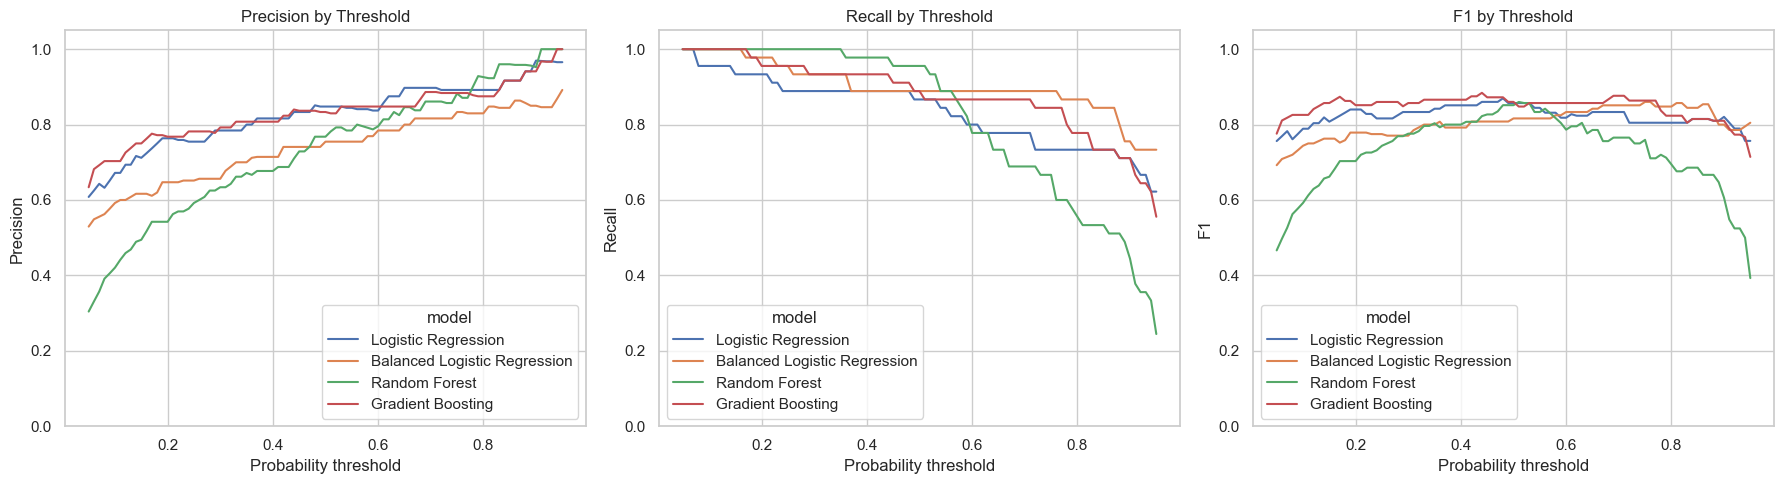

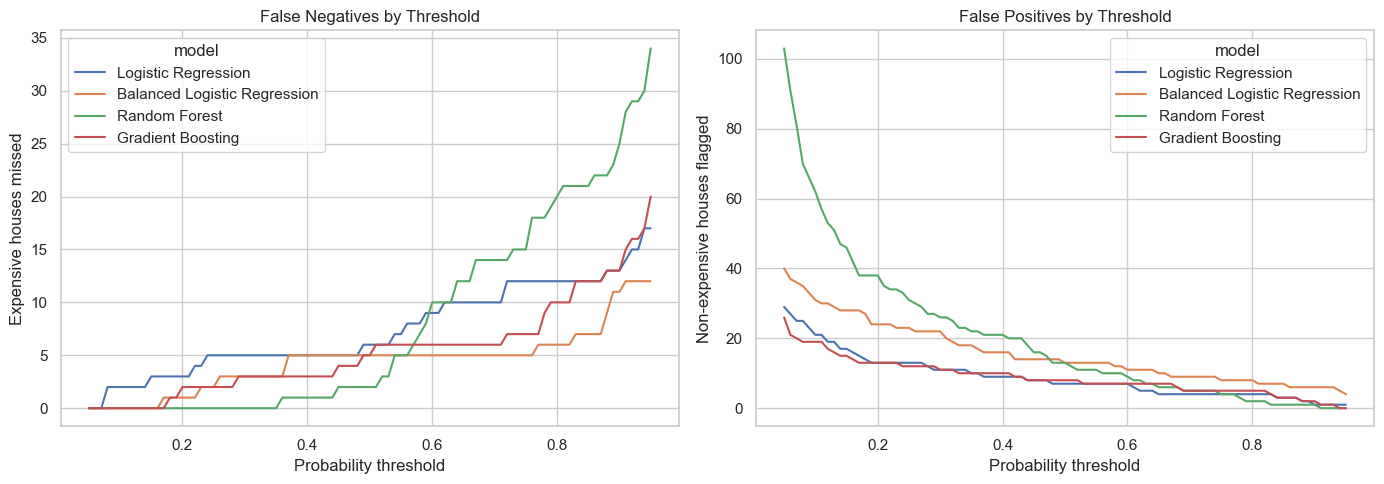

,model,threshold,precision,recall,f1,false_negatives,false_positives
312,Gradient Boosting,0.44,0.840,0.933,0.884,3,8
43,Logistic Regression,0.48,0.851,0.889,0.870,5,7
161,Balanced Logistic Regression,0.75,0.833,0.889,0.860,5,8
228,Random Forest,0.51,0.782,0.956,0.860,2,12


In [143]:
threshold_grid = np.linspace(0.05, 0.95, 91)
threshold_curve_rows = []

for name, model in best_estimators.items():
    if name == "Dummy baseline" or not hasattr(model, "predict_proba"):
        continue

    proba = model.predict_proba(X_test)[:, 1]
    for threshold in threshold_grid:
        pred = (proba >= threshold).astype(int)
        cm = confusion_matrix(y_test, pred)
        threshold_curve_rows.append({
            "model": name,
            "threshold": threshold,
            "precision": precision_score(y_test, pred, zero_division=0),
            "recall": recall_score(y_test, pred, zero_division=0),
            "f1": f1_score(y_test, pred, zero_division=0),
            "false_negatives": int(cm[1, 0]),
            "false_positives": int(cm[0, 1]),
        })

threshold_curve_df = pd.DataFrame(threshold_curve_rows)

curve_models = [m for m in ["Logistic Regression", "Balanced Logistic Regression", "Random Forest", "Gradient Boosting"] if m in threshold_curve_df["model"].unique()]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for metric, ax in zip(["precision", "recall", "f1"], axes):
    sns.lineplot(
        data=threshold_curve_df[threshold_curve_df["model"].isin(curve_models)],
        x="threshold",
        y=metric,
        hue="model",
        ax=ax,
    )
    ax.set_title(f"{metric.title()} by Threshold")
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Probability threshold")
    ax.set_ylabel(metric.title())

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=threshold_curve_df[threshold_curve_df["model"].isin(curve_models)],
    x="threshold",
    y="false_negatives",
    hue="model",
    ax=axes[0],
)
axes[0].set_title("False Negatives by Threshold")
axes[0].set_xlabel("Probability threshold")
axes[0].set_ylabel("Expensive houses missed")

sns.lineplot(
    data=threshold_curve_df[threshold_curve_df["model"].isin(curve_models)],
    x="threshold",
    y="false_positives",
    hue="model",
    ax=axes[1],
)
axes[1].set_title("False Positives by Threshold")
axes[1].set_xlabel("Probability threshold")
axes[1].set_ylabel("Non-expensive houses flagged")

plt.tight_layout()
plt.show()

best_threshold_points = threshold_curve_df.loc[
    threshold_curve_df.groupby("model")["f1"].idxmax(),
    ["model", "threshold", "precision", "recall", "f1", "false_negatives", "false_positives"]
].sort_values("f1", ascending=False)

display(best_threshold_points.round(3))

**Threshold-curve interpretation:** Lower thresholds usually increase recall and reduce false negatives, but they also increase false positives. Higher thresholds do the opposite. The final threshold should reflect the real business cost of missing expensive houses versus reviewing too many non-expensive ones.

**Threshold interpretation:** The threshold table above summarises the same tradeoff numerically, making it easier to compare candidate thresholds across models.

### Final Model and Feature Importance
The default-threshold comparison table is used to select a final model for interpretation. Permutation importance shows which cleaned features most affect model performance.

Selected final model: Gradient Boosting


,feature,importance_mean,importance_std
79,TotalSF,3.424658e-02,0.009686
16,OverallQual,3.065068e-02,0.009532
36,BsmtUnfSF,2.910959e-03,0.002239
11,Neighborhood,2.910959e-03,0.002239
43,2ndFlrSF,2.739726e-03,0.002055
29,BsmtQual,2.054795e-03,0.002740
26,ExterQual,1.883562e-03,0.001704
3,LotArea,1.541096e-03,0.002534
76,YrSold,1.198630e-03,0.001633
45,GrLivArea,5.136986e-04,0.004092


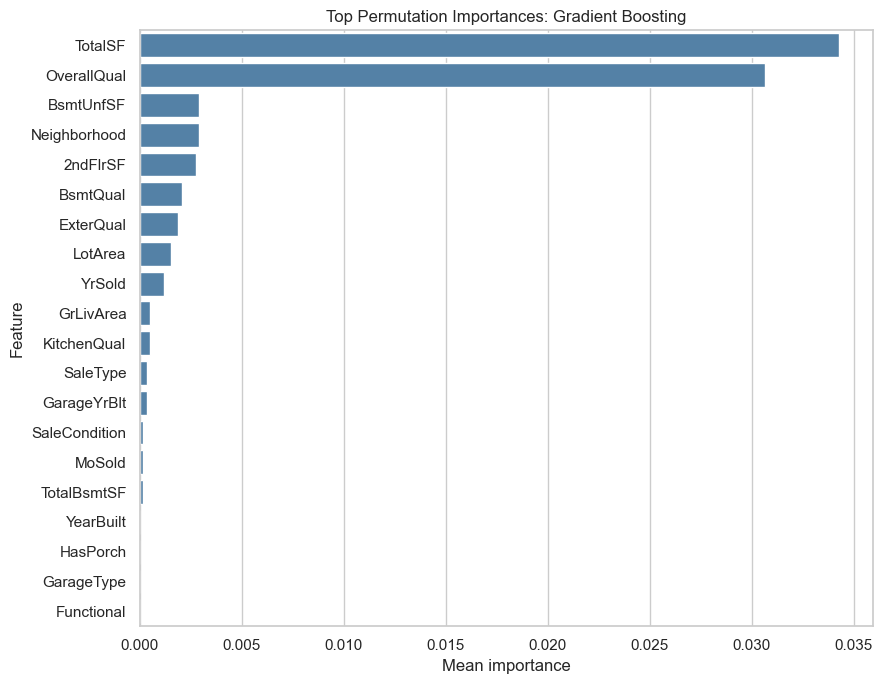

In [144]:
final_model_name = results_df.iloc[0]["model"]
final_model = best_estimators[final_model_name]

print("Selected final model:", final_model_name)

perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(9, 7))
sns.barplot(data=importance_df.head(20), x="importance_mean", y="feature", color="steelblue")
plt.title(f"Top Permutation Importances: {final_model_name}")
plt.xlabel("Mean importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Feature-importance interpretation:** The strongest features should connect back to the EDA: quality, living area, total square footage, neighbourhood, and other structural features are expected to matter most. If a top feature is surprising, it should be investigated before trusting the model.

### Predict Kaggle Test Classification Labels
The Kaggle `test.csv` has no true `SalePrice`, so these are not validation results. This step uses the default `0.5` threshold to create predicted expensive-house labels and probabilities for the unlabelled Kaggle rows.

In [145]:
test_proba = final_model.predict_proba(clean_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

kaggle_classification_predictions = pd.DataFrame({
    "Id": raw_test["Id"],
    "Expensive_probability": test_proba,
    "Expensive_prediction": test_pred,
})

print("Predicted expensive houses in Kaggle test set:", int(kaggle_classification_predictions["Expensive_prediction"].sum()))
display(kaggle_classification_predictions.head(10))

Predicted expensive houses in Kaggle test set: 214


,Id,Expensive_probability,Expensive_prediction
0,1461,0.000750,0
1,1462,0.004674,0
2,1463,0.001021,0
3,1464,0.001344,0
4,1465,0.004673,0
5,1466,0.001338,0
6,1467,0.005357,0
7,1468,0.000997,0
8,1469,0.003529,0
9,1470,0.000976,0


### Modelling Summary
This modelling section compares a baseline, logistic models, Random Forest, and Gradient Boosting. The final model should be selected using expensive-class F1, recall, PR-AUC, and false negatives rather than accuracy alone. The prepared Kaggle test predictions are classification outputs only; they are not a Kaggle `SalePrice` submission.